# Tabular Deep Learning - FX Pairs

Can a rank-1 adapter MLP ensemble improve one-day FX rankings after linear
and boosted-tree models plateau at low validation IC? This notebook compares
three TabM capacities on the same 61-feature, 20-pair learning task.

**Learning Objectives**:
- Evaluate TabM checkpoints with pooled decision-time rank IC
- Require complete walk-forward coverage before selecting a checkpoint
- Compare TabM with the signed linear and GBM baselines
- Interpret a small IC difference using daily HAC uncertainty

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and
[`02_labels`](02_labels.ipynb)

In [1]:
"""TabM capacity and checkpoint comparison for one-day FX rankings."""

import hashlib
import json

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml

import utils.style as style
from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.registry import compute_prediction_fold_metrics
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.cv_splits import generate_cv_splits
from utils.modeling import (
    ConfigError,
    _replace_temporal_columns,
    load_configs,
    load_modeling_dataset,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

In [2]:
CASE_STUDY_ID = "fx_pairs"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100  # Frozen registry cache key and reader-default fresh-run budget.
BATCH_SIZE = 4096
DEVICE = "cpu"  # Deterministic reader-default path for a fresh run.
SEED = 42

In [3]:
set_global_seeds(SEED)
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
PRIMARY_LABEL = PRIMARY_LABEL or setup["labels"]["primary"]

if setup["labels"]["primary"] != PRIMARY_LABEL:
    raise ConfigError(
        f"{PRIMARY_LABEL!r} has no matching fold-aware temporal artifact. "
        f"Run this notebook with the primary label {setup['labels']['primary']!r}."
    )

print(f"Case study: {CASE_STUDY_ID} | Label: {PRIMARY_LABEL} | Device: {DEVICE}")

Case study: fx_pairs | Label: fwd_ret_1d | Device: cpu


## 1. Load the Signed Learning Task

Fold boundaries come from `cv_config.json`, the same contract used to create
the fold-aware temporal features. The sealed holdout is not loaded or scored.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"

cv_config = json.loads((CASE_DIR / "config" / "cv_config.json").read_text())
splits = generate_cv_splits(
    dataset,
    cv_config=cv_config,
    label_buffer=mds.label_buffer,
    date_col=date_col,
)
splits = [
    {
        **split,
        **{
            key: pd.Timestamp(split[key])
            for key in ("train_start", "train_end", "val_start", "val_end")
        },
    }
    for split in splits[: MAX_FOLDS or None]
]

print(f"Dataset: {len(dataset):,} rows x {len(feature_names)} features")
print(f"Task: {mds.task_type} | Entities: {dataset[entity_col].n_unique()} | Folds: {len(splits)}")

Dataset: 77,440 rows x 61 features
Task: regression | Entities: 20 | Folds: 8


## 2. Audit Fold Alignment

Each fold ID must select its matching temporal artifact. The audit checks all
61 inputs and rejects an all-missing temporal feature before model fitting.

In [5]:
dataset_pd = dataset.to_pandas()
dates = pd.to_datetime(dataset_pd[date_col])

for split in splits:
    train_mask = (dates >= split["train_start"]) & (dates <= split["train_end"])
    val_mask = (dates >= split["val_start"]) & (dates <= split["val_end"])
    train_df = _replace_temporal_columns(
        dataset_pd,
        train_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    val_df = _replace_temporal_columns(
        dataset_pd,
        val_mask,
        mds.temporal_by_fold,
        mds.temporal_keys,
        mds.temporal_feature_names,
        split["fold"],
    )
    missing_temporal = [
        name
        for name in mds.temporal_feature_names
        if train_df[name].isna().all() or val_df[name].isna().all()
    ]
    if len(feature_names) != train_df[feature_names].shape[1]:
        raise ConfigError(f"Fold {split['fold']} did not retain all {len(feature_names)} features")
    if missing_temporal:
        raise ConfigError(
            f"Fold {split['fold']} has no observations for temporal features: {missing_temporal}"
        )
    print(f"  Fold {split['fold']}: train={len(train_df):,}  val={len(val_df):,}")

  Fold 0: train=24,840  val=5,420


  Fold 1: train=25,940  val=5,300
  Fold 2: train=26,560  val=5,340
  Fold 3: train=26,920  val=4,600
  Fold 4: train=26,120  val=5,420


  Fold 5: train=26,160  val=5,400


  Fold 6: train=26,140  val=5,320
  Fold 7: train=26,160  val=5,360


## 3. Reconstruct or Train the TabM Grid

TabM is a shared MLP backbone with rank-1 member adapters and separate output
heads. It is not an attention model. On the complete frozen registry, the
runner reads prediction files without writing and separates every physical
epoch before scoring. The legacy training key says 100 epochs, while each
physical file contains checkpoints through epoch 200; file contents therefore
determine the frozen curve. A fresh output root trains the 100-epoch grid on CPU.

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")
for config in tabdl_configs:
    if N_EPOCHS > 0:
        config["n_epochs"] = N_EPOCHS
    config["batch_size"] = BATCH_SIZE

effective_epochs = max(config.get("n_epochs", 200) for config in tabdl_configs)
print(f"Grid: {len(tabdl_configs)} configs x up to {effective_epochs} epochs x {len(splits)} folds")
for config in tabdl_configs:
    params = config["params"]
    print(
        f"  {config['config_name']:8s} hidden={params['hidden_dim']:3d}  "
        f"members={params['n_members']:2d}  dropout={params['dropout']:.1f}"
    )

Grid: 3 configs x up to 100 epochs x 8 folds
  tabm_s   hidden= 64  members= 4  dropout=0.1
  tabm_m   hidden=128  members= 8  dropout=0.1
  tabm_l   hidden=256  members=16  dropout=0.1


In [7]:
def _file_md5(path):
    """Return a compact immutability check for the frozen registry."""
    if not path.exists():
        return None
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "md5").hexdigest()


registry_path = CASE_DIR / "run_log" / "registry.db"
registry_before = _file_md5(registry_path)
result = run_tabm_cv(
    dataset_pd,
    splits,
    feature_names=feature_names,
    label_col=label_col,
    date_col=date_col,
    entity_col=entity_col,
    configs=tabdl_configs,
    n_features=len(feature_names),
    device=DEVICE,
    save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
    register=True,
    force_retrain=FORCE_RETRAIN,
    prediction_split=PREDICTION_SPLIT,
    case_study=CASE_STUDY_ID,
    notebook="08_tabular_dl",
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
)
registry_after = _file_md5(registry_path)
frozen_mode = result["training_log"].is_empty() and registry_before is not None
if frozen_mode and registry_after != registry_before:
    raise RuntimeError("The frozen TabM reader path modified registry.db")

print(f"Mode: {'frozen physical reconstruction' if frozen_mode else 'current CPU training'}")

  SKIP tabm_s                     (complete (hash=0fd83d9ab0d4), split=validation)
  SKIP tabm_m                     (complete (hash=a584d604296b), split=validation)
  SKIP tabm_l                     (complete (hash=ff2a113a3bc9), split=validation)
All configs already registered - rebuilding result from frozen registry.


Mode: frozen physical reconstruction


Physical checkpoint files are ranked by pooled daily IC. A candidate must have
finite predictions, positive IC coverage, every expected fold, and the maximum
validation-date count. Fresh and frozen branches use this same selector and
return the same coverage fields to the reader-facing summary.

In [8]:
grid_results = result["grid_results"]
curves = result["all_learning_curves"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
predictions = result["predictions"]

headline, _ = compute_prediction_fold_metrics(
    predictions,
    date_col=date_col,
    entity_col=entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    label=label_col,
)
best_ic = float(headline["ic_mean_daily"])

grid_table = pl.DataFrame(grid_results).select(
    pl.col("config_name").alias("config"),
    pl.col("best_epoch").alias("epoch"),
    pl.col("best_ic").alias("pooled_daily_ic"),
    "ic_n_days",
    "n_invalid",
    "selectable",
)
grid_table

config,epoch,pooled_daily_ic,ic_n_days,n_invalid,selectable
str,i64,f64,i64,i64,bool
"""tabm_s""",25,0.009619,2064,0,true
"""tabm_l""",100,0.006621,2064,0,true
"""tabm_m""",50,0.002532,2064,0,true


## 4. Architecture Comparison

The small model leads this frozen vintage at epoch 25. The gap over the signed
linear and GBM baselines is descriptive, not evidence of a dependable edge.

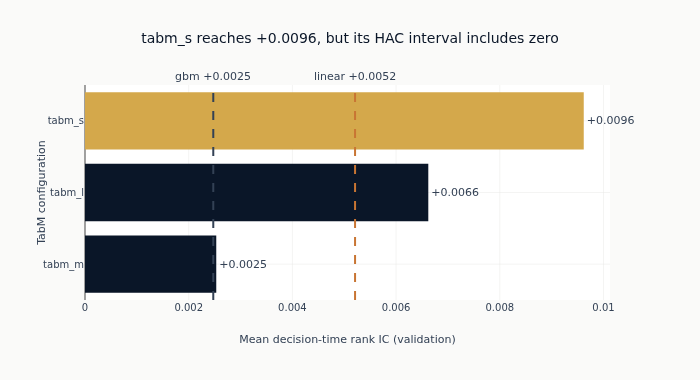

In [9]:
baseline_rows = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID]).select(
    "family", "ic_mean"
)
baselines = dict(baseline_rows.iter_rows())

ranked_grid = sorted(grid_results, key=lambda row: row["best_ic"])
grid_figure = go.Figure(
    go.Bar(
        x=[row["best_ic"] for row in ranked_grid],
        y=[row["config_name"] for row in ranked_grid],
        orientation="h",
        marker_color=[
            style.COLORS["amber"] if row["config_name"] == best_name else style.COLORS["blue"]
            for row in ranked_grid
        ],
        text=[f"{row['best_ic']:+.4f}" for row in ranked_grid],
        textposition="outside",
        cliponaxis=False,
    )
)
for family, color in (("linear", "copper"), ("gbm", "neutral")):
    if family in baselines:
        grid_figure.add_vline(
            x=baselines[family],
            line=dict(color=style.COLORS[color], dash="dash"),
            annotation_text=f"{family} {baselines[family]:+.4f}",
            annotation_position="top",
        )
grid_figure.update_layout(
    template="ml4t",
    title=f"{best_name} reaches {best_ic:+.4f}, but its HAC interval includes zero",
    xaxis_title="Mean decision-time rank IC (validation)",
    yaxis_title="TabM configuration",
    height=380,
    margin=dict(l=85, r=90, t=85),
    showlegend=False,
)
grid_figure.show()

## 5. Checkpoint Stability

Extra training does not improve the small model: its peak occurs at the first
saved checkpoint, while the larger variants follow different, unstable paths.

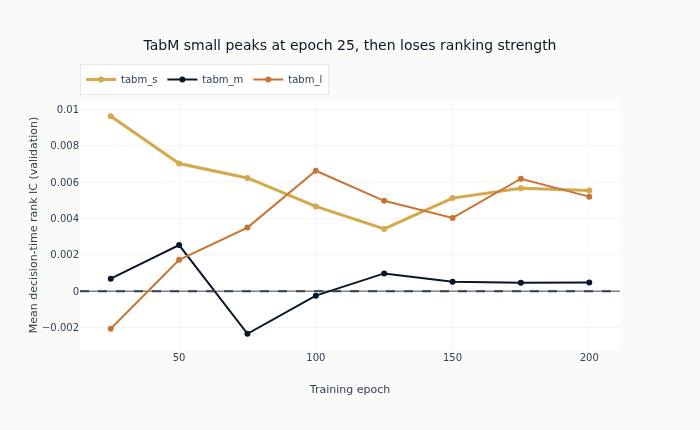

In [10]:
curve_figure = go.Figure()
curve_colors = {
    "tabm_s": style.COLORS["amber"],
    "tabm_m": style.COLORS["blue"],
    "tabm_l": style.COLORS["copper"],
}
for config_name in curves["config"].unique(maintain_order=True):
    config_curve = curves.filter(pl.col("config") == config_name).sort("epoch")
    curve_figure.add_trace(
        go.Scatter(
            x=config_curve["epoch"].to_list(),
            y=config_curve["ic_mean"].to_list(),
            mode="lines+markers",
            name=config_name,
            line=dict(
                color=curve_colors.get(config_name, style.COLORS["neutral"]),
                width=3 if config_name == best_name else 2,
            ),
        )
    )
curve_figure.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
curve_figure.update_layout(
    template="ml4t",
    title="TabM small peaks at epoch 25, then loses ranking strength",
    xaxis_title="Training epoch",
    yaxis_title="Mean decision-time rank IC (validation)",
    height=430,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
)
curve_figure.show()

## 6. Uncertainty and Fold Dispersion

Daily HAC inference treats dates, not pair-level rows, as observations. The
selected checkpoint spans 2,064 validation dates, yet its 95% interval crosses
zero and its fold signs vary. The comparison therefore remains weak.

In [11]:
fold_metrics = result["fold_metrics"]
print(f"Selected: {best_name} at epoch {best_epoch}")
print(f"Pooled daily IC: {best_ic:+.4f} across {int(headline['ic_n_days']):,} dates")
print(
    f"HAC 95% CI: [{headline['ic_ci_lo']:+.4f}, {headline['ic_ci_hi']:+.4f}]  "
    f"t={headline['ic_t_hac']:.2f}  p={headline['ic_p_hac']:.3f}  "
    f"lag={int(headline['ic_hac_lag'])}"
)
fold_metrics

Selected: tabm_s at epoch 25
Pooled daily IC: +0.0096 across 2,064 dates
HAC 95% CI: [-0.0035, +0.0227]  t=1.44  p=0.149  lag=7


fold_id,ic_mean,n_test
i64,f64,i64
0,0.012432,5160
1,-0.014839,5160
2,-0.008842,5160
3,0.033135,5160
4,0.022953,5160
5,0.011914,5160
6,0.003177,5160
7,0.017025,5160


## 7. Result Disposition

The default execution reconstructed 24 physical config-epoch checkpoints from
three legacy prediction files. It did not trust the mixed-file registry metric
and did not modify the frozen registry.

In [12]:
print(f"Selected predictions: {predictions.height:,} rows")
print(f"All physical checkpoint predictions: {result['all_predictions'].height:,} rows")
print(f"Checkpoint summaries: {curves.height:,} rows")
print(f"Registry unchanged: {registry_before == registry_after if frozen_mode else 'fresh run'}")

Selected predictions: 41,280 rows
All physical checkpoint predictions: 990,720 rows
Checkpoint summaries: 24 rows
Registry unchanged: True


## 8. Key Takeaways

1. **The physical winner is TabM small at epoch 25.** Its pooled daily IC is
   +0.0096, compared with +0.0052 for Ridge and +0.0025 for the GBM winner.
2. **The difference is not statistically resolved.** The daily HAC interval is
   [-0.0035, +0.0227] with p=0.149, and two of eight folds are negative.
3. **More capacity and training do not form a stable pattern.** Medium peaks at
   +0.0025 and large at +0.0066; the small model weakens after epoch 25.
4. **The book's rounded +0.007 used a mixed-epoch file metric.** Separating the
   same frozen predictions changes it to +0.010 without changing the conclusion.
   The corrected current-vintage CPU rerun belongs in the v3.1 measurement backlog.

**Next**: [`09_dl_tcn`](09_dl_tcn.ipynb) tests whether temporal convolutions add
stable ranking information beyond the flat feature matrix.